# Bengali Sign Language Classification using CNN
### Part II - Computer Vision Assessment

## Setting up - Mount Drive and Extract Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
zip_file_path = "/content/drive/MyDrive/Datasets/Sign Language Detection.zip"
extract_path = "/content/sign_language"

!unzip -q "{zip_file_path}" -d "{extract_path}"

print(f"Successfully extracted to '{extract_path}'.")

Successfully extracted to '/content/sign_language'.


## Importing libraries

In [3]:
!pip install split-folders -q

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import splitfolders
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix

print('tensorflow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

tensorflow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Dataset Understanding

In [5]:
train_path = '/content/sign_language/Sign Language Detection/Train'

# getting all class folders, sorting numerically
classes = sorted(os.listdir(train_path), key=lambda x: int(x))
print('total classes:', len(classes))
print('classes:', classes)

total = 0
for c in classes:
    total += len(os.listdir(os.path.join(train_path, c)))
print('total images in train folder:', total)

total classes: 38
classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37']
total images in train folder: 11058


In [6]:
from PIL import Image

removed = []
for cls in os.listdir(train_path):
    folder = os.path.join(train_path, cls)
    if not os.path.isdir(folder):
        continue
    for fname in os.listdir(folder):
        fpath = os.path.join(folder, fname)
        try:
            img = Image.open(fpath)
            img.verify()
        except:
            os.remove(fpath)
            removed.append(fpath)

print(f'removed {len(removed)} corrupted images')

removed 266 corrupted images


In [7]:
# checking how many images per class
counts = []
for c in classes:
    n = len(os.listdir(os.path.join(train_path, c)))
    counts.append(n)

print('min:', min(counts))
print('max:', max(counts))
print('mean:', round(sum(counts)/len(counts), 2))

min: 239
max: 293
mean: 284.0


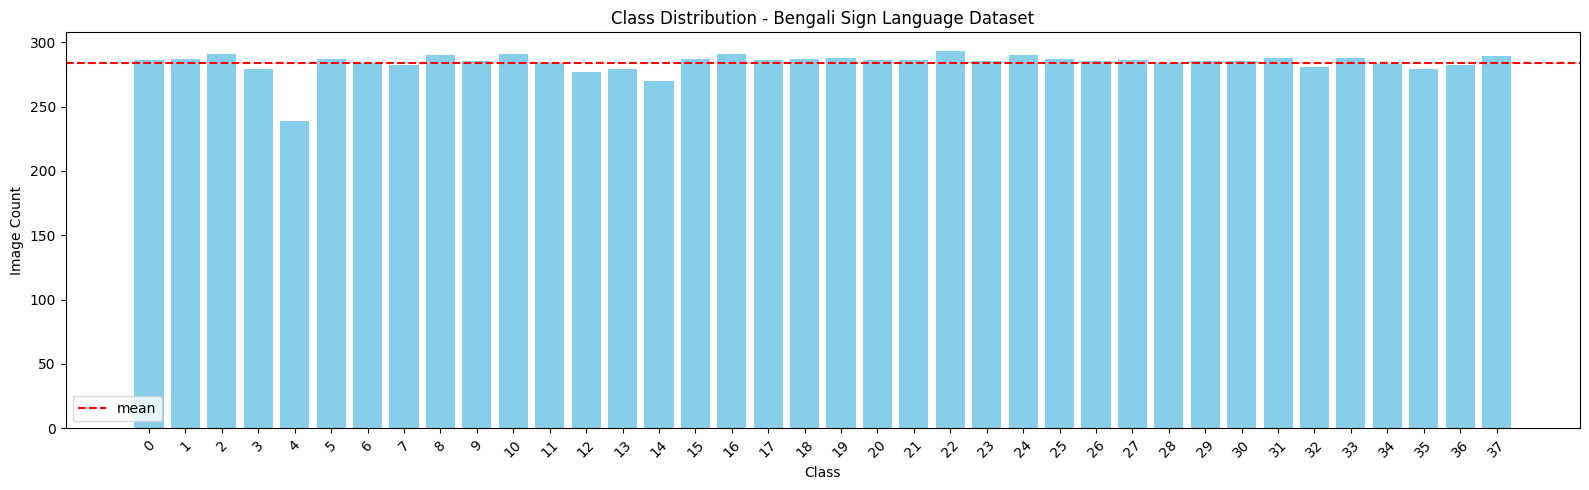

In [8]:
# class distribution
plt.figure(figsize=(16,5))
plt.bar(classes, counts, color='skyblue')
plt.axhline(y=np.mean(counts), color='red', linestyle='--', label='mean')
plt.xlabel('Class')
plt.ylabel('Image Count')
plt.title('Class Distribution - Bengali Sign Language Dataset')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


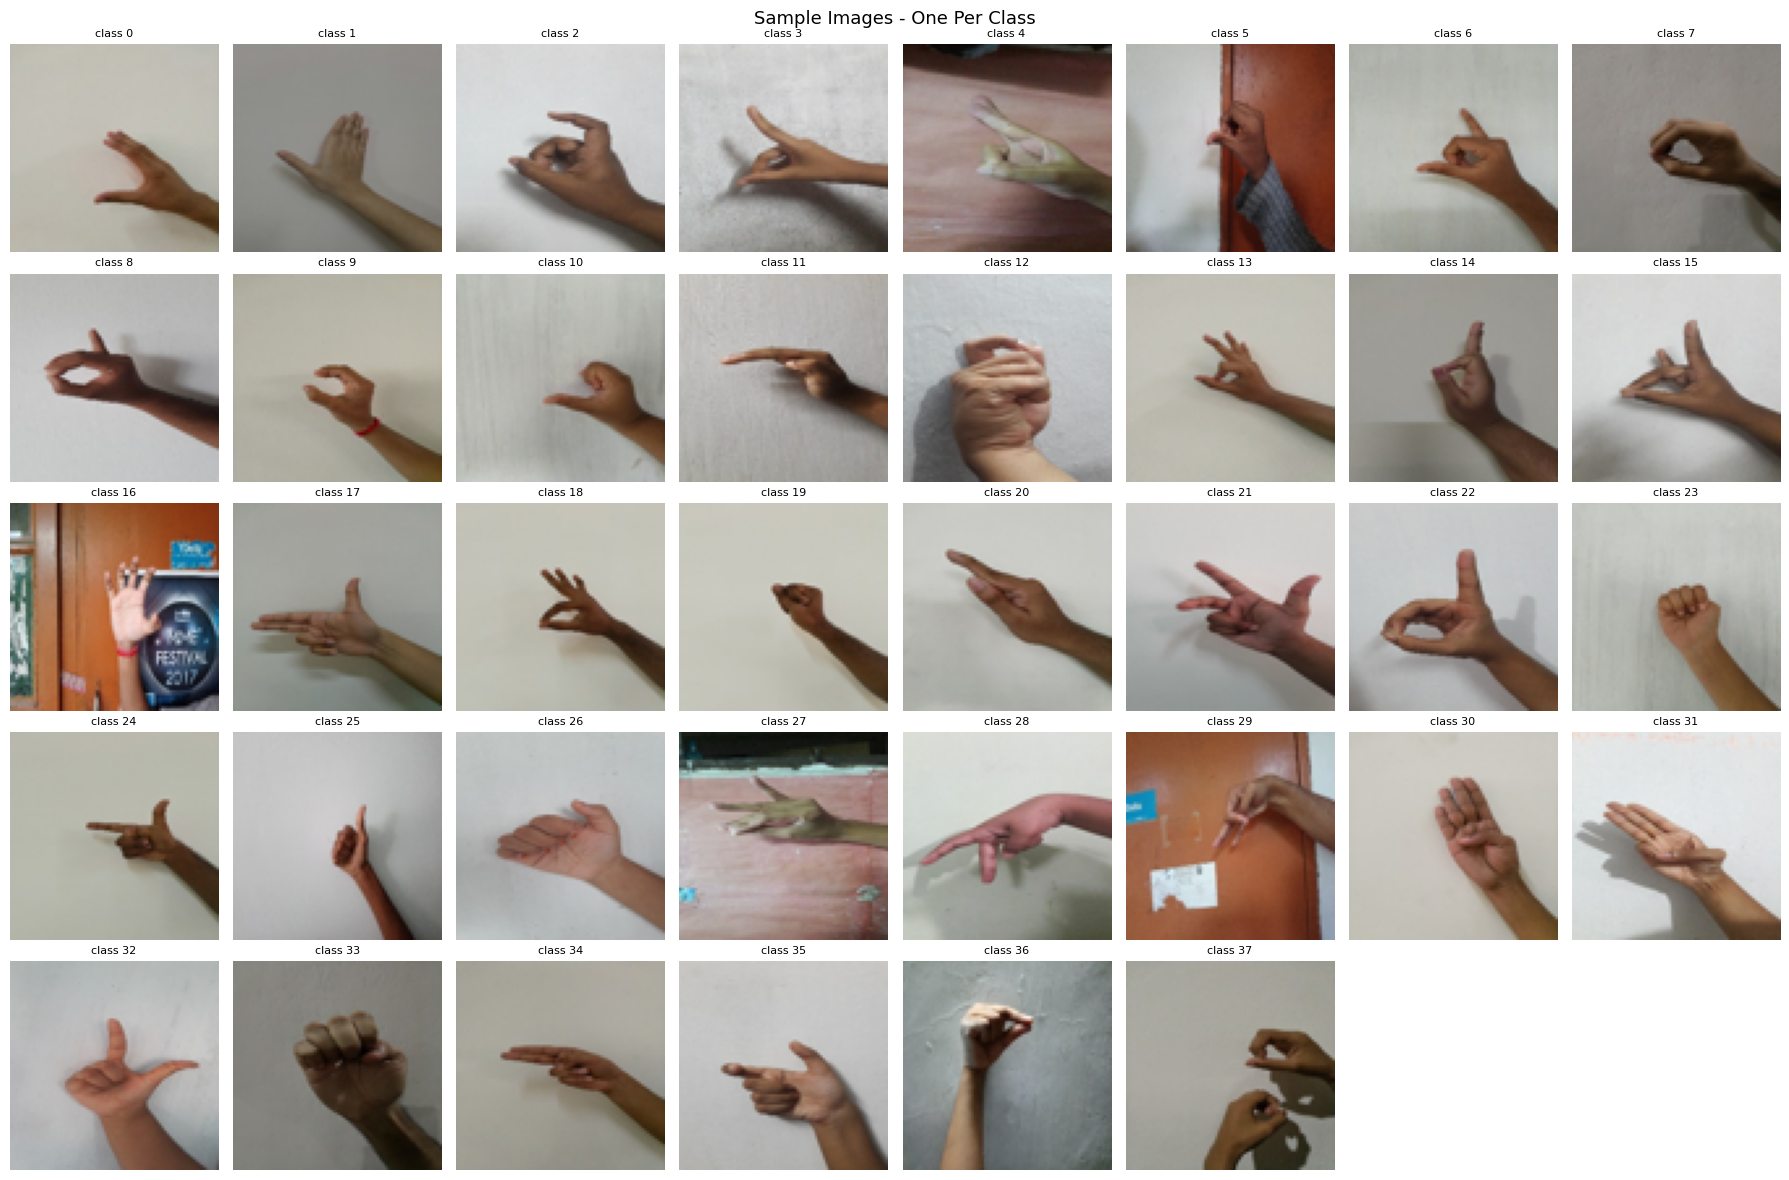

In [9]:
# showing sample images from each class
fig, axes = plt.subplots(5, 8, figsize=(18, 12))
axes = axes.flatten()

for i, cls in enumerate(classes):
    folder = os.path.join(train_path, cls)
    img_name = os.listdir(folder)[0]
    img = Image.open(os.path.join(folder, img_name)).resize((80,80))
    axes[i].imshow(img)
    axes[i].set_title(f'class {cls}', fontsize=8)
    axes[i].axis('off')

# hide leftover axes
for j in range(len(classes), len(axes)):
    axes[j].axis('off')

plt.suptitle('Sample Images - One Per Class', fontsize=13)
plt.tight_layout()
plt.show()

## Preprocessing - Splitting and Augmentation

In [10]:
# splitting into train/val/test
splitfolders.ratio(
    train_path,
    output='/content/split_data',
    seed=42,
    ratio=(0.8, 0.1, 0.1)
)
print('split done')

Copying files: 10792 files [00:06, 1787.70 files/s]

split done


In [11]:
IMG_SIZE = (128, 128)
BATCH = 32
NUM_CLASSES = len(classes)

# augmenting train data a bit to help with overfitting
train_gen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    '/content/split_data/train',
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='categorical'
)

val_data = val_test_gen.flow_from_directory(
    '/content/split_data/val',
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='categorical'
)

test_data = val_test_gen.flow_from_directory(
    '/content/split_data/test',
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='categorical',
    shuffle=False
)

print('train:', train_data.samples)
print('val  :', val_data.samples)
print('test :', test_data.samples)

Found 8618 images belonging to 38 classes.
Found 1060 images belonging to 38 classes.
Found 1114 images belonging to 38 classes.
train: 8618
val  : 1060
test : 1114


---
## Part A - Building CNN From Scratch

### Baseline Model
Starting with a simple CNN - 3 conv layers and 3 dense layers to set a baseline

In [14]:
def baseline_cnn(input_shape, num_classes):
    model = models.Sequential(name='baseline_cnn')

    model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D(2,2))

    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    return model

model1 = baseline_cnn((128, 128, 3), NUM_CLASSES)
model1.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 38)             │         2,470 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,525,734 (32.52 MB)

 Trainable params: 8,525,734 (32.52 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model1.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

print('training baseline model...')
history1 = model1.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[es]
)

training baseline model...
Epoch 1/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 57s 184ms/step - accuracy: 0.0406 - loss: 3.5961 - val_accuracy: 0.0849 - val_loss: 3.3883
Epoch 2/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 47s 175ms/step - accuracy: 0.1199 - loss: 3.2497 - val_accuracy: 0.1726 - val_loss: 2.8793
Epoch 3/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 45s 167ms/step - accuracy: 0.2114 - loss: 2.7599 - val_accuracy: 0.3311 - val_loss: 2.2112
Epoch 4/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 44s 164ms/step - accuracy: 0.3292 - loss: 2.2647 - val_accuracy: 0.4519 - val_loss: 1.7565
Epoch 5/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 44s 165ms/step - accuracy: 0.4110 - loss: 1.9381 - val_accuracy: 0.5113 - val_loss: 1.5086
Epoch 6/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 44s 165ms/step - accuracy: 0.4810 - loss: 1.6733 - val_accuracy: 0.5764 - val_loss: 1.3206
Epoch 7/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 45s 168ms/step - accuracy: 0.5389 - loss: 1.4956 - val_accuracy: 0.6528 - val_loss: 1.1044
Epoch 8/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 46s 171ms/step -

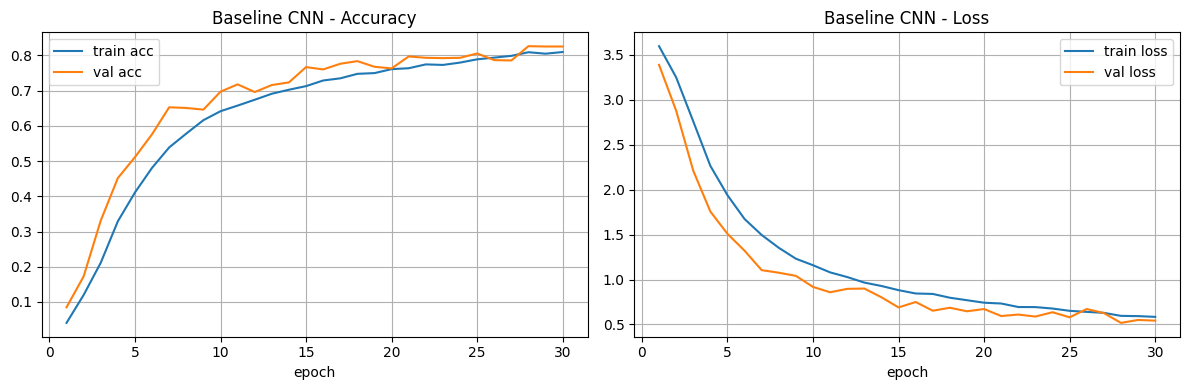

In [16]:

# plotting accuracy and loss
def plot_curves(hist, title):
    acc = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']
    loss = hist.history['loss']
    val_loss = hist.history['val_loss']
    ep = range(1, len(acc)+1)

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(ep, acc, label='train acc')
    plt.plot(ep, val_acc, label='val acc')
    plt.title(title + ' - Accuracy')
    plt.xlabel('epoch')
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(ep, loss, label='train loss')
    plt.plot(ep, val_loss, label='val loss')
    plt.title(title + ' - Loss')
    plt.xlabel('epoch')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_curves(history1, 'Baseline CNN')

In [17]:
# evaluate on test set
loss1, acc1 = model1.evaluate(test_data, verbose=0)
print(f'baseline test accuracy: {acc1*100:.2f}%')
print(f'baseline test loss: {loss1:.4f}')

baseline test accuracy: 78.19%
baseline test loss: 0.7638


In [18]:
# classification report
test_data.reset()
preds1 = np.argmax(model1.predict(test_data, verbose=0), axis=1)
true1 = test_data.classes

print(classification_report(true1, preds1, target_names=classes))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80        30
           1       0.79      0.87      0.83        30
           2       0.90      0.87      0.88        30
           3       0.89      0.86      0.88        29
           4       0.72      0.79      0.75        29
           5       0.69      0.76      0.72        29
           6       0.96      0.89      0.92        27
           7       0.87      0.67      0.75        30
           8       0.93      0.93      0.93        30
           9       0.76      0.87      0.81        30
          10       0.56      0.73      0.64        30
          11       0.71      0.57      0.63        30
          12       0.96      0.73      0.83        30
          13       0.70      0.77      0.73        30
          14       0.87      0.90      0.89        30
          15       0.81      0.70      0.75        30
          16       0.62      0.69      0.66        29
          17       0.75    

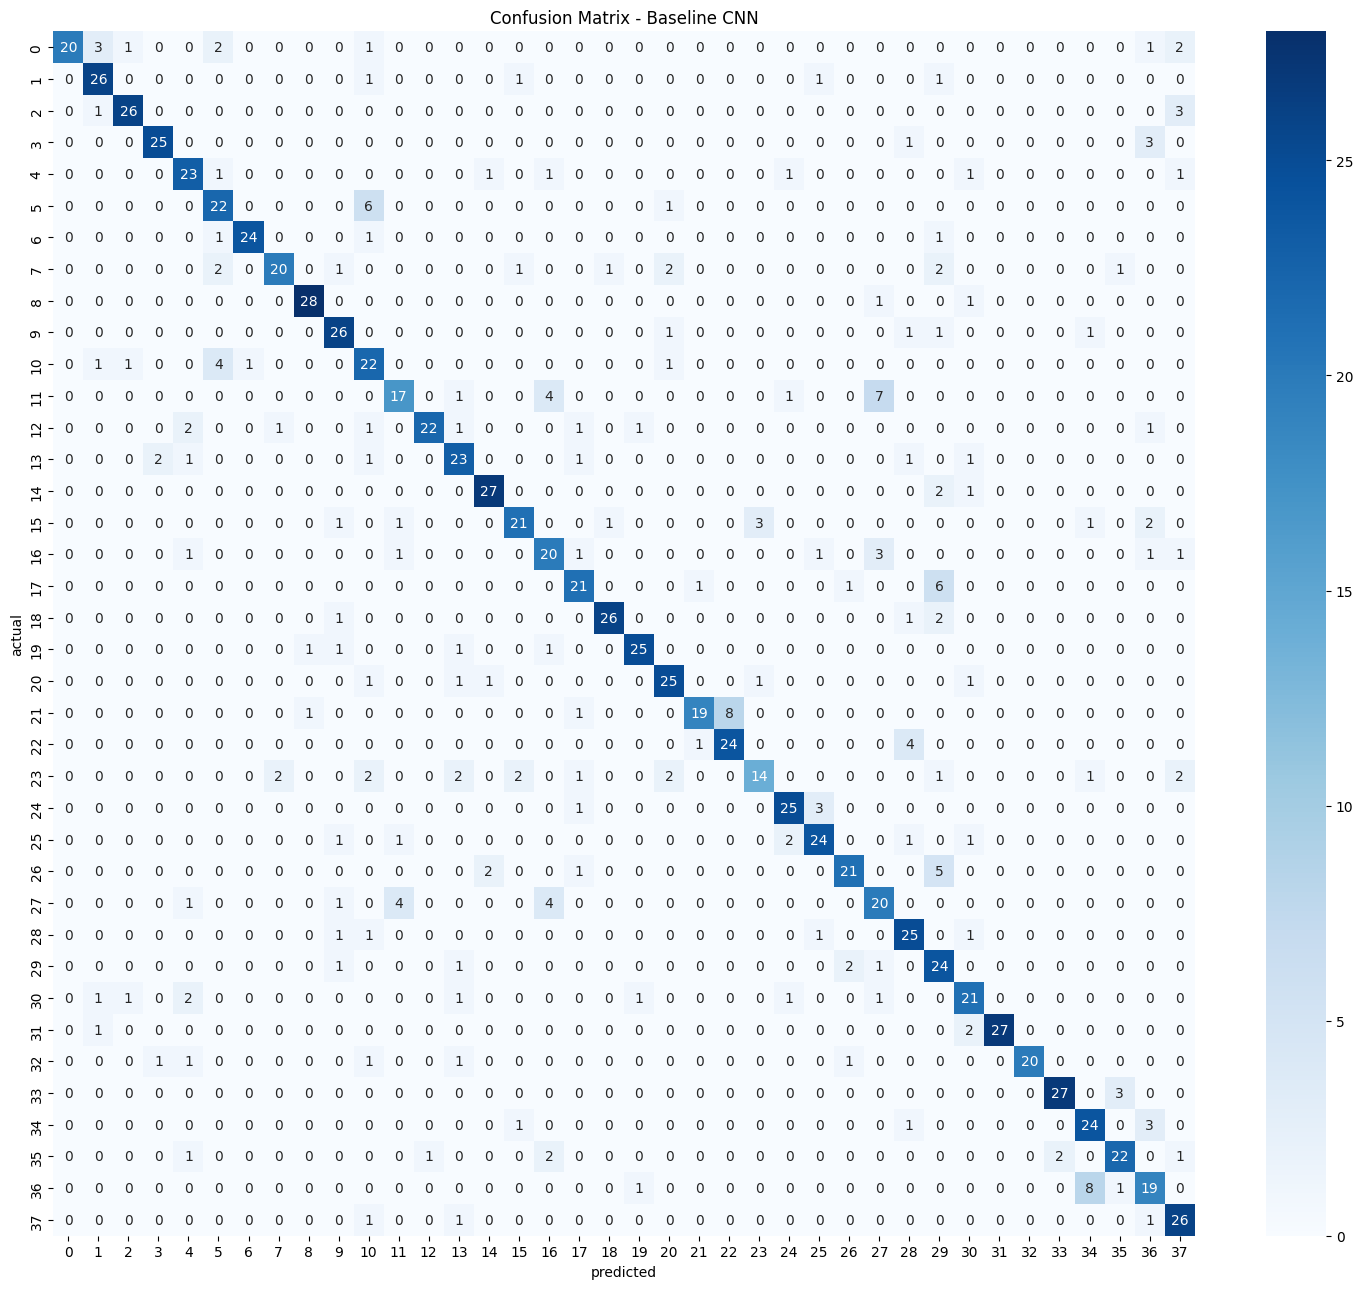

In [19]:
# confusion matrix
cm1 = confusion_matrix(true1, preds1)

plt.figure(figsize=(15,13))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - Baseline CNN')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.tight_layout()
plt.show()

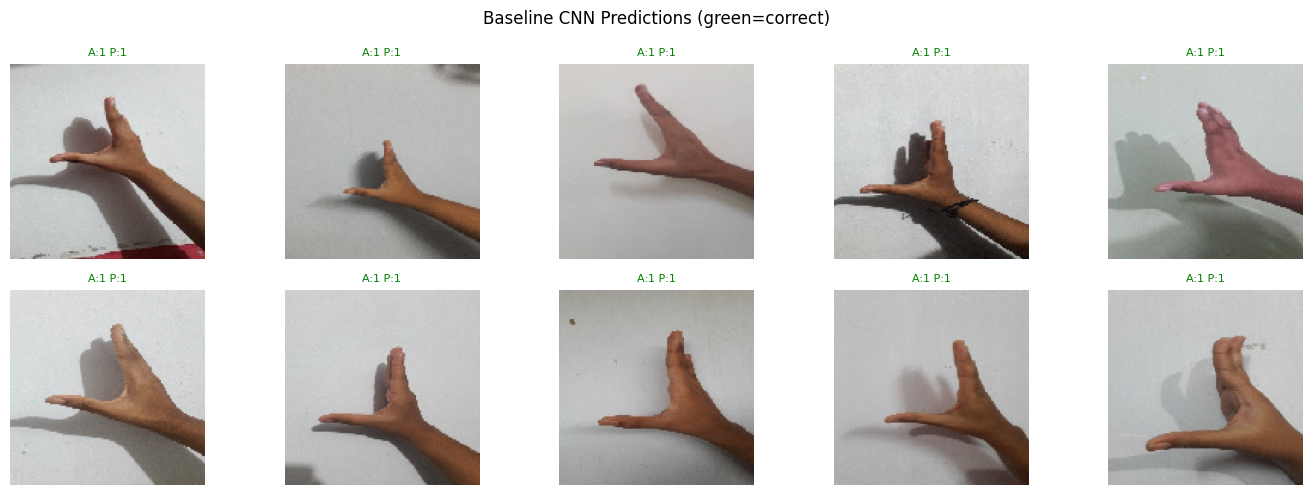

In [21]:
# checking some predictions visually
imgs, lbls = next(test_data)
pred_classes = np.argmax(model1.predict(imgs, verbose=0), axis=1)
actual_classes = np.argmax(lbls, axis=1)

plt.figure(figsize=(14,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(imgs[i])
    color = 'green' if pred_classes[i]==actual_classes[i] else 'red'
    plt.title(f'A:{classes[actual_classes[i]]} P:{classes[pred_classes[i]]}', color=color, fontsize=8)
    plt.axis('off')
plt.suptitle('Baseline CNN Predictions (green=correct)')
plt.tight_layout()
plt.show()

### Deeper CNN Model
Adding more conv layers, batch normalization and dropout to improve on baseline

In [24]:
def deep_cnn(input_shape, num_classes):
    model = models.Sequential(name='deep_cnn')

    # block 1
    model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D(2,2))
    model.add(Dropout(0.25))

    # block 2
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D(2,2))
    model.add(Dropout(0.25))

    # block 3
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D(2,2))
    model.add(Dropout(0.25))

    # block 4 - added more depth
    model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2,2))
    model.add(Dropout(0.25))

    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))

    return model

model2 = deep_cnn((128,128,3), NUM_CLASSES)
model2.summary()

Model: "deep_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,116,358 (34.78 MB)

 Trainable params: 9,114,374 (34.77 MB)

 Non-trainable params: 1,984 (7.75 KB)

training deeper model with adam...
Epoch 1/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 86s 245ms/step - accuracy: 0.0591 - loss: 3.9658 - val_accuracy: 0.0406 - val_loss: 5.9666
Epoch 2/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 50s 184ms/step - accuracy: 0.0963 - loss: 3.5691 - val_accuracy: 0.1019 - val_loss: 3.4270
Epoch 3/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 49s 182ms/step - accuracy: 0.1382 - loss: 3.1800 - val_accuracy: 0.1925 - val_loss: 2.9778
Epoch 4/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 49s 182ms/step - accuracy: 0.1992 - loss: 2.8126 - val_accuracy: 0.1575 - val_loss: 3.3098
Epoch 5/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 49s 180ms/step - accuracy: 0.2777 - loss: 2.4303 - val_accuracy: 0.2113 - val_loss: 2.6629
Epoch 6/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 50s 186ms/step - accuracy: 0.3605 - loss: 2.1156 - val_accuracy: 0.5264 - val_loss: 1.5510
Epoch 7/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 50s 183ms/step - accuracy: 0.4134 - loss: 1.9171 - val_accuracy: 0.4943 - val_loss: 1.6360
Epoch 8/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 51s 187m

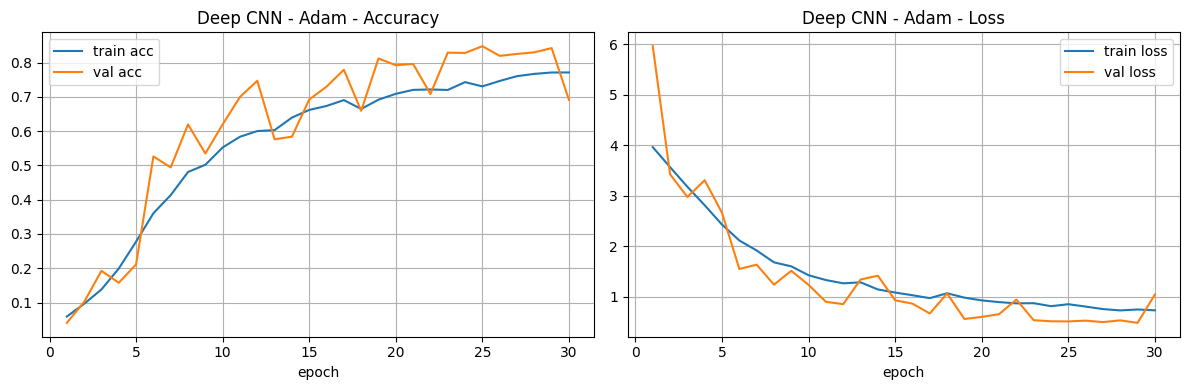

In [25]:
model2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

print('training deeper model with adam...')
history2_adam = model2.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[es]
)

plot_curves(history2_adam, 'Deep CNN - Adam')

In [26]:
loss2_adam, acc2_adam = model2.evaluate(test_data, verbose=0)
print(f'deep cnn (adam) test accuracy: {acc2_adam*100:.2f}%')

deep cnn (adam) test accuracy: 82.32%


## Experimentation

### Optimizer Comparison - SGD vs Adam
Training same deep model with SGD to see which optimizer works better

training same model with sgd...
Epoch 1/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 71s 217ms/step - accuracy: 0.0602 - loss: 4.0943 - val_accuracy: 0.1255 - val_loss: 3.3462
Epoch 2/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 48s 177ms/step - accuracy: 0.0862 - loss: 3.5221 - val_accuracy: 0.1085 - val_loss: 3.2938
Epoch 3/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 48s 177ms/step - accuracy: 0.1172 - loss: 3.2969 - val_accuracy: 0.1274 - val_loss: 3.3935
Epoch 4/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 46s 172ms/step - accuracy: 0.1519 - loss: 3.0657 - val_accuracy: 0.1340 - val_loss: 3.2576
Epoch 5/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 49s 180ms/step - accuracy: 0.1826 - loss: 2.8725 - val_accuracy: 0.0651 - val_loss: 6.1033
Epoch 6/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 48s 176ms/step - accuracy: 0.2317 - loss: 2.6574 - val_accuracy: 0.2179 - val_loss: 2.7642
Epoch 7/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 48s 177ms/step - accuracy: 0.2709 - loss: 2.4593 - val_accuracy: 0.3840 - val_loss: 2.1485
Epoch 8/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 50s 184ms/s

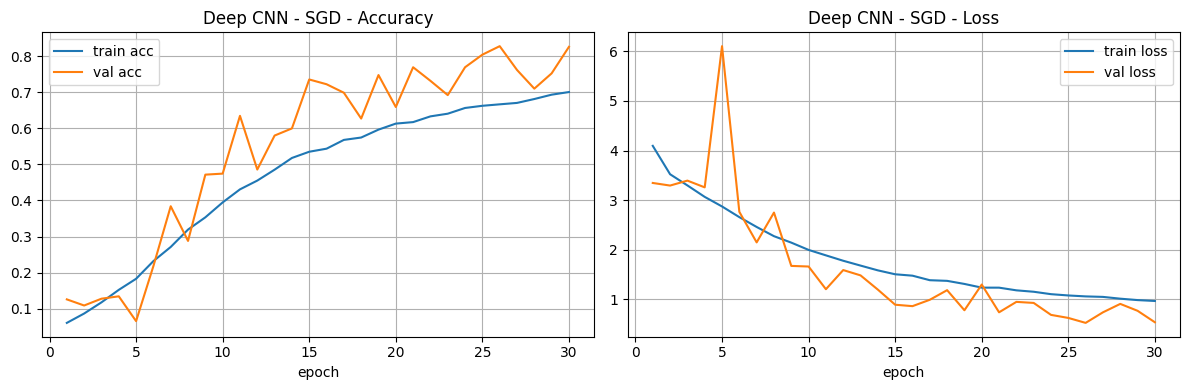

In [28]:
# rebuilding same architecture but with SGD
model2_sgd = deep_cnn((128,128,3), NUM_CLASSES)
model2_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

print('training same model with sgd...')
history2_sgd = model2_sgd.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[es]
)

plot_curves(history2_sgd, 'Deep CNN - SGD')

In [29]:
loss2_sgd, acc2_sgd = model2_sgd.evaluate(test_data, verbose=0)
print(f'deep cnn (sgd)  accuracy: {acc2_sgd*100:.2f}%')
print(f'deep cnn (adam) accuracy: {acc2_adam*100:.2f}%')

deep cnn (sgd)  accuracy: 79.89%
deep cnn (adam) accuracy: 82.32%


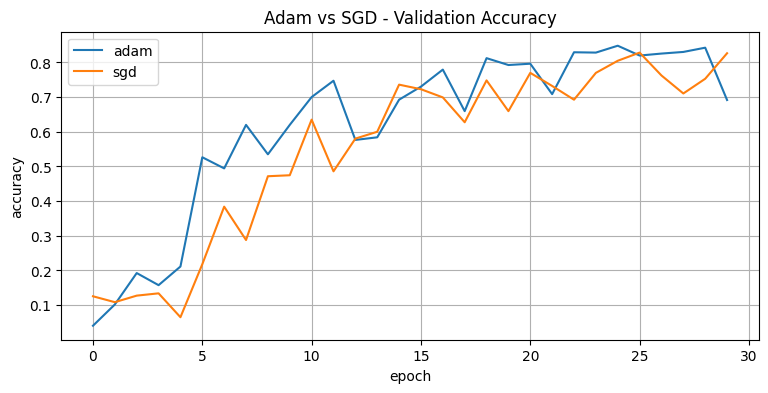

In [30]:
# comparing val accuracy of both optimizers
plt.figure(figsize=(9,4))
plt.plot(history2_adam.history['val_accuracy'], label='adam')
plt.plot(history2_sgd.history['val_accuracy'], label='sgd')
plt.title('Adam vs SGD - Validation Accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)
plt.show()

##What happens if we remove Dropout?

In [32]:
# same deep model but no dropout - to see how much dropout actually helps
def deep_cnn_no_dropout(input_shape, num_classes):
    model = models.Sequential(name='no_dropout')

    model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D(2,2))

    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(2,2))

    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dense(256, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))

    return model

model_ablation = deep_cnn_no_dropout((128,128,3), NUM_CLASSES)
model_ablation.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

print('training no-dropout model...')
history_ablation = model_ablation.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[es]
)

loss_abl, acc_abl = model_ablation.evaluate(test_data, verbose=0)
print(f'no dropout - test accuracy: {acc_abl*100:.2f}%')
print(f'with dropout - test accuracy: {acc2_adam*100:.2f}%')

training no-dropout model...
Epoch 1/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 61s 196ms/step - accuracy: 0.0651 - loss: 3.9871 - val_accuracy: 0.0274 - val_loss: 6.2968
Epoch 2/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 47s 175ms/step - accuracy: 0.1366 - loss: 3.1390 - val_accuracy: 0.1679 - val_loss: 2.9452
Epoch 3/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 48s 176ms/step - accuracy: 0.2511 - loss: 2.5350 - val_accuracy: 0.0906 - val_loss: 3.3023
Epoch 4/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 48s 179ms/step - accuracy: 0.3606 - loss: 2.0879 - val_accuracy: 0.4528 - val_loss: 1.7708
Epoch 5/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 47s 172ms/step - accuracy: 0.4564 - loss: 1.7621 - val_accuracy: 0.5415 - val_loss: 1.4223
Epoch 6/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 47s 176ms/step - accuracy: 0.5158 - loss: 1.5501 - val_accuracy: 0.5368 - val_loss: 1.5103
Epoch 7/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 48s 178ms/step - accuracy: 0.5755 - loss: 1.3529 - val_accuracy: 0.6160 - val_loss: 1.1892
Epoch 8/30
270/270 ━━━━━━━━━━━━━━━━━━━━ 47s 174ms/step

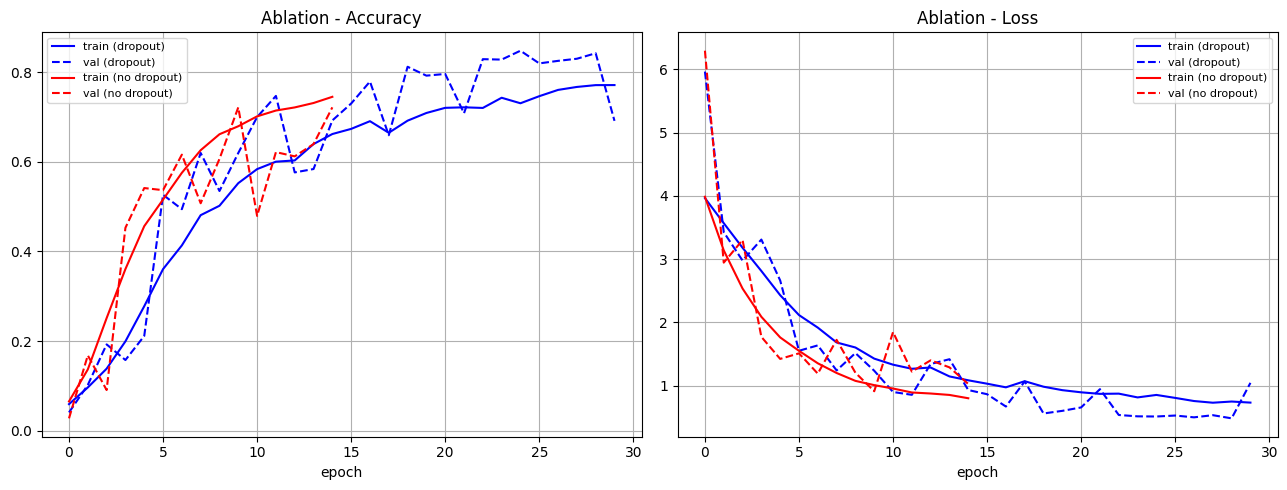

In [34]:
# comparing overfitting gap between dropout vs no dropout
plt.figure(figsize=(13,5))

plt.subplot(1,2,1)
plt.plot(history2_adam.history['accuracy'], label='train (dropout)', color='blue')
plt.plot(history2_adam.history['val_accuracy'], label='val (dropout)', color='blue', linestyle='--')
plt.plot(history_ablation.history['accuracy'], label='train (no dropout)', color='red')
plt.plot(history_ablation.history['val_accuracy'], label='val (no dropout)', color='red', linestyle='--')
plt.title('Ablation - Accuracy')
plt.xlabel('epoch'); plt.legend(fontsize=8); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history2_adam.history['loss'], label='train (dropout)', color='blue')
plt.plot(history2_adam.history['val_loss'], label='val (dropout)', color='blue', linestyle='--')
plt.plot(history_ablation.history['loss'], label='train (no dropout)', color='red')
plt.plot(history_ablation.history['val_loss'], label='val (no dropout)', color='red', linestyle='--')
plt.title('Ablation - Loss')
plt.xlabel('epoch'); plt.legend(fontsize=8); plt.grid(True)

plt.tight_layout()
plt.show()


### Summary: Baseline vs Deep Model

In [35]:
summary = pd.DataFrame({
    'Model'       : ['Baseline CNN', 'Deep CNN (Adam)', 'Deep CNN (SGD)', 'No Dropout CNN'],
    'Test Acc'    : [f'{acc1*100:.2f}%', f'{acc2_adam*100:.2f}%', f'{acc2_sgd*100:.2f}%', f'{acc_abl*100:.2f}%'],
    'Test Loss'   : [f'{loss1:.4f}', f'{loss2_adam:.4f}', f'{loss2_sgd:.4f}', f'{loss_abl:.4f}'],
    'BatchNorm'   : ['No','Yes','Yes','Yes'],
    'Dropout'     : ['No','Yes','Yes','No'],
    'Optimizer'   : ['Adam','Adam','SGD','Adam']
})

print(summary.to_string(index=False))

          Model Test Acc Test Loss BatchNorm Dropout Optimizer
   Baseline CNN   78.19%    0.7638        No      No      Adam
Deep CNN (Adam)   82.32%    0.5980       Yes     Yes      Adam
 Deep CNN (SGD)   79.89%    0.6949       Yes     Yes       SGD
 No Dropout CNN   66.07%    1.1052       Yes      No      Adam


---
## Part B - Transfer Learning with MobileNetV2

Using MobileNetV2 pretrained on imagenet. First doing feature extraction (frozen), then fine-tuning.

In [36]:
# MobileNetV2 needs at least 96x96 so remaking generators
IMG_TL = (96, 96)

tl_train = ImageDataGenerator(
    rescale=1./255, horizontal_flip=True, rotation_range=10, zoom_range=0.1
).flow_from_directory(
    '/content/split_data/train', target_size=IMG_TL, batch_size=BATCH, class_mode='categorical'
)

tl_val = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/content/split_data/val', target_size=IMG_TL, batch_size=BATCH, class_mode='categorical'
)

tl_test = ImageDataGenerator(rescale=1./255).flow_from_directory(
    '/content/split_data/test', target_size=IMG_TL, batch_size=BATCH,
    class_mode='categorical', shuffle=False
)

Found 8618 images belonging to 38 classes.
Found 1060 images belonging to 38 classes.
Found 1114 images belonging to 38 classes.


In [37]:
# loading mobilenetv2, removing top layer
base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(96,96,3))
base.trainable = False  # freezing all layers first

print('base model layers:', len(base.layers))
print('trainable:', base.trainable)

# adding my own layers on top
tl_model = models.Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(NUM_CLASSES, activation='softmax')
], name='mobilenetv2_fe')

tl_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
base model layers: 154
trainable: False


Model: "mobilenetv2_fe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,596,710 (9.91 MB)

 Trainable params: 338,214 (1.29 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

training mobilenetv2 - feature extraction...
Epoch 1/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 77s 215ms/step - accuracy: 0.5135 - loss: 1.7231 - val_accuracy: 0.6868 - val_loss: 1.0121
Epoch 2/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 30s 110ms/step - accuracy: 0.7031 - loss: 0.9815 - val_accuracy: 0.7472 - val_loss: 0.8548
Epoch 3/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 30s 110ms/step - accuracy: 0.7550 - loss: 0.7998 - val_accuracy: 0.7708 - val_loss: 0.7475
Epoch 4/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 31s 116ms/step - accuracy: 0.7812 - loss: 0.7089 - val_accuracy: 0.7736 - val_loss: 0.7291
Epoch 5/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 30s 111ms/step - accuracy: 0.7960 - loss: 0.6587 - val_accuracy: 0.7915 - val_loss: 0.6848
Epoch 6/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 29s 108ms/step - accuracy: 0.8037 - loss: 0.6221 - val_accuracy: 0.7896 - val_loss: 0.7205
Epoch 7/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 29s 109ms/step - accuracy: 0.8070 - loss: 0.5997 - val_accuracy: 0.7943 - val_loss: 0.6523
Epoch 8/20
270/270 ━━━━━━━━━━━━━━━━━━━

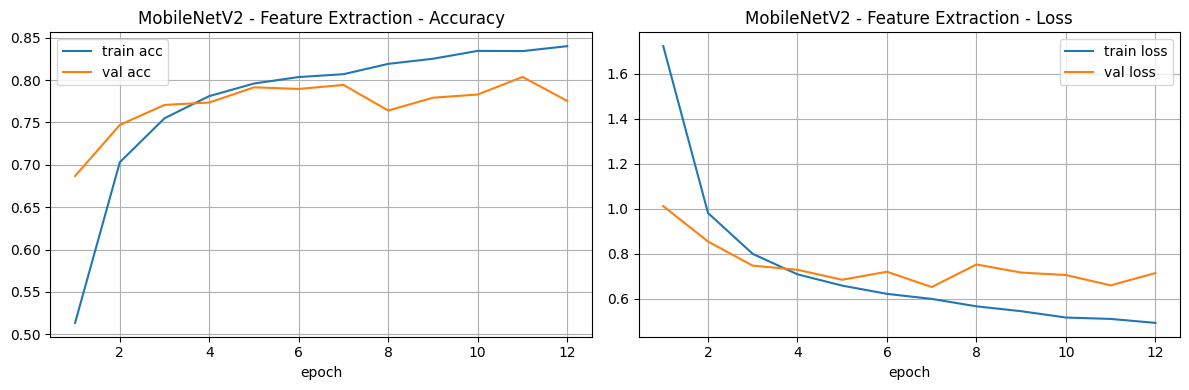

feature extraction accuracy: 72.71%


In [38]:
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

print('training mobilenetv2 - feature extraction...')
history_fe = tl_model.fit(
    tl_train,
    validation_data=tl_val,
    epochs=20,
    callbacks=[es]
)

plot_curves(history_fe, 'MobileNetV2 - Feature Extraction')

loss_fe, acc_fe = tl_model.evaluate(tl_test, verbose=0)
print(f'feature extraction accuracy: {acc_fe*100:.2f}%')

### Fine Tuning - Unfreezing Last 30 Layers

unfrozen layers: 30
fine tuning mobilenetv2...
Epoch 1/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 64s 168ms/step - accuracy: 0.6911 - loss: 1.0105 - val_accuracy: 0.7802 - val_loss: 0.7339
Epoch 2/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 30s 110ms/step - accuracy: 0.8027 - loss: 0.6054 - val_accuracy: 0.7877 - val_loss: 0.7155
Epoch 3/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 31s 113ms/step - accuracy: 0.8483 - loss: 0.4722 - val_accuracy: 0.8057 - val_loss: 0.6182
Epoch 4/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 32s 118ms/step - accuracy: 0.8668 - loss: 0.4089 - val_accuracy: 0.8377 - val_loss: 0.5294
Epoch 5/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 30s 111ms/step - accuracy: 0.8832 - loss: 0.3538 - val_accuracy: 0.8481 - val_loss: 0.4983
Epoch 6/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 29s 108ms/step - accuracy: 0.9033 - loss: 0.2954 - val_accuracy: 0.8528 - val_loss: 0.5011
Epoch 7/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 30s 112ms/step - accuracy: 0.9108 - loss: 0.2645 - val_accuracy: 0.8415 - val_loss: 0.4897
Epoch 8/20
270/270 ━━━━━━━━━━━━━━━━━

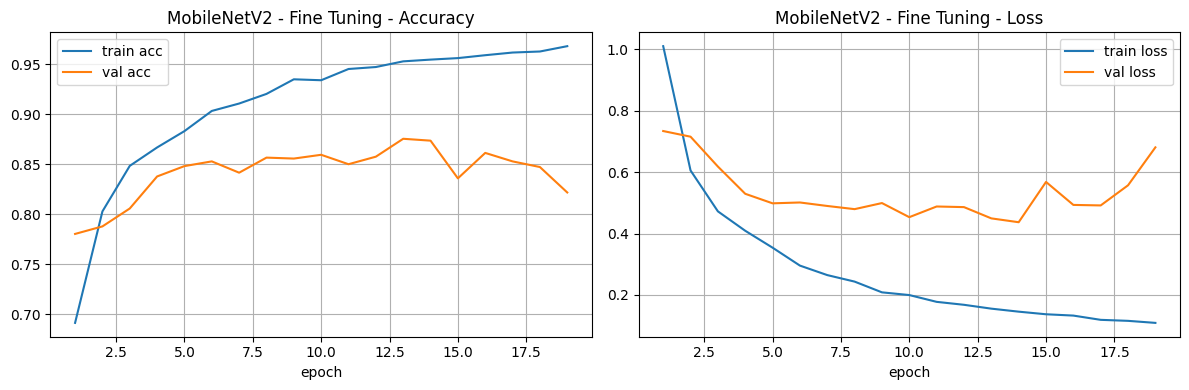

fine tuned accuracy: 84.11%


In [39]:
# unfreezing top layers for fine tuning
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

trainable = sum(1 for l in base.layers if l.trainable)
print(f'unfrozen layers: {trainable}')

# lower lr for fine tuning so we dont destroy pretrained weights
tl_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

print('fine tuning mobilenetv2...')
history_ft = tl_model.fit(
    tl_train,
    validation_data=tl_val,
    epochs=20,
    callbacks=[es]
)

plot_curves(history_ft, 'MobileNetV2 - Fine Tuning')

loss_ft, acc_ft = tl_model.evaluate(tl_test, verbose=0)
print(f'fine tuned accuracy: {acc_ft*100:.2f}%')

## Final Comparison - All Models

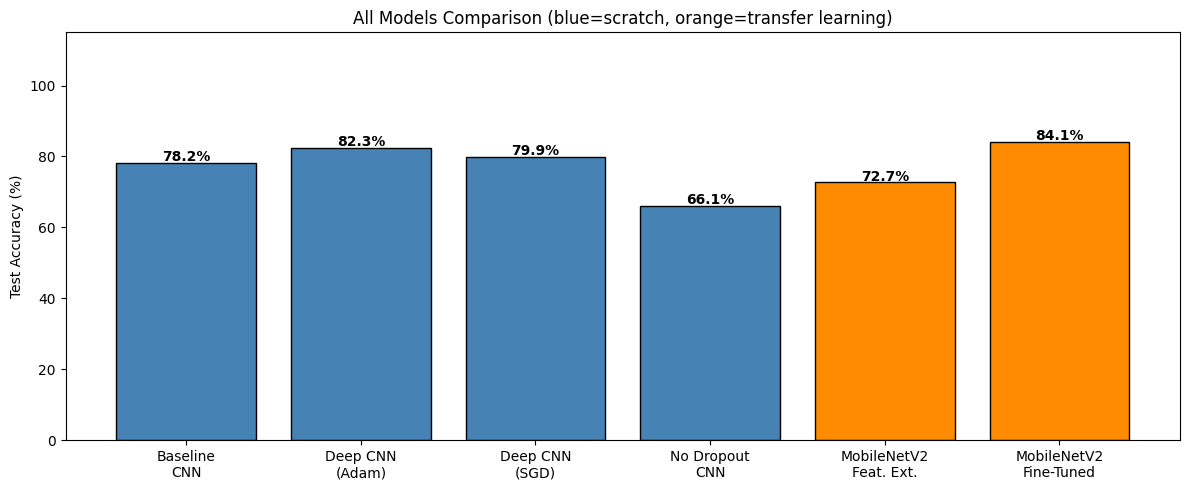

In [42]:
all_models = ['Baseline\nCNN', 'Deep CNN\n(Adam)', 'Deep CNN\n(SGD)', 'No Dropout\nCNN', 'MobileNetV2\nFeat. Ext.', 'MobileNetV2\nFine-Tuned']
all_acc    = [acc1, acc2_adam, acc2_sgd, acc_abl, acc_fe, acc_ft]
colors     = ['steelblue','steelblue','steelblue','steelblue','darkorange','darkorange']

plt.figure(figsize=(12,5))
bars = plt.bar(all_models, [a*100 for a in all_acc], color=colors, edgecolor='black')
for bar, a in zip(bars, all_acc):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{a*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.ylabel('Test Accuracy (%)')
plt.title('All Models Comparison (blue=scratch, orange=transfer learning)')
plt.ylim(0, 115)
plt.tight_layout()
plt.show()

In [43]:
final_table = pd.DataFrame({
    'Model'  : ['Baseline CNN', 'Deep CNN (Adam)', 'Deep CNN (SGD)', 'No Dropout CNN', 'MobileNetV2 FE', 'MobileNetV2 FT'],
    'Acc'    : [f'{a*100:.2f}%' for a in all_acc],
    'Type'   : ['Scratch','Scratch','Scratch','Scratch','Transfer','Transfer']
})
print(final_table.to_string(index=False))

          Model    Acc     Type
   Baseline CNN 78.19%  Scratch
Deep CNN (Adam) 82.32%  Scratch
 Deep CNN (SGD) 79.89%  Scratch
 No Dropout CNN 66.07%  Scratch
 MobileNetV2 FE 72.71% Transfer
 MobileNetV2 FT 84.11% Transfer


In [44]:
# saving models
model1.save('baseline_cnn.keras')
model2.save('deep_cnn_adam.keras')
tl_model.save('mobilenetv2_ft.keras')
print('models saved')

models saved
